# Aufgabe 3

In dieser Aufgabe betrachten wir einen Serienschwingkreis welcher ein einfacher RCL-Schwingkeris ist wo alle Komponenten in Serie geschalten wurden, in dem wir die Transferfunktion $|U_R/U_0|$ und die Phasenverschiebung $\theta$ als Funktion der Frequenz messen. Dabei galt der Schaltplan @schaltplan3
![Schaltkreis für die 3. Aufgabe](./figures/Abbildung3.png){#fig-schaltplan}

Der Stromkreis besteht aus der Eingangsspannung $U_0$ (Frequenzgenerator), Spule mit Induktivität $L$ und Widerstand $R_{sp}$, Kondensator mit Kapazität $C$ Lastwiderstand $R_d$ (in dem wir $U_R$ messen) und der Gesamtwiderstand der Schaltung: $R_{ges} = R_d + R_{sp}$

## Herleitung der Transferfunktion
Die Gesamtimpedanz der Schaltung ist:
$$Z = R_d + R_{sp} + j\left(\omega L - \frac{1}{\omega C}\right)$$

wobei:
- $R_d + R_{sp}$ der Gesamtwiderstand ist
- $X = \omega L - \frac{1}{\omega C}$ die Reaktanz (Blindwiderstand)
- $\omega = 2\pi f$ die Kreisfrequenz ist

Die komplexe Übertragungsfunktion ist das Verhältnis der Spannungen. Der Gesamtstrom in der Schaltung ist:
$$I = \frac{U_0}{Z}$$

Die Spannung über dem Widerstand $R_d$ ist:
$$U_R = I \cdot R_d = \frac{U_0 \cdot R_d}{Z}$$

Damit ist die komplexe Transferfunktion:
$$H(\omega) = \frac{U_R}{U_0} = \frac{R_d}{R_d + R_{sp} + j\left(\omega L - \frac{1}{\omega C}\right)}$$

Für den Betrag der Transferfunktion nehmen wir $|H(\omega)|$:
$$|H(\omega)| = \frac{R_d}{\sqrt{(R_d + R_{sp})^2 + \left(\omega L - \frac{1}{\omega C}\right)^2}}$$

So erhält man die Transferfunktinskurve, die im Plot gefittet wurde.

Die Phase der komplexen Transferfunktion, beschriebt die Phasenverschiebung zwischen Eingangsspannung $U_0$ und Ausgangsspannung $U_R$ und ist:
$$\text{arg}(H(\omega)) = -\arctan\left(\frac{\omega L - \frac{1}{\omega C}}{R_d + R_{sp}}\right)$$

Mit der Formel können wir unsere Messdaten fitten, aus den Fitparametern $L$, $C$, und $R_{sp}$ berechnen wir wie gesucht:

1. Das Widerstandsverhältnis:
$$r = \frac{R_d}{R_d + R_{sp}}$$

2. Die Dämpfungskonstante:
$$\delta = \frac{R_d + R_{sp}}{2L}$$

3. Die ungedämpfte Resonanzfrequenz als Resonanzfrequenz des idealen LC-Schwingkreises:
$$f_0 = \frac{1}{2\pi\sqrt{LC}}$$

Dabei sind alle Formeln alle aus der Aufgabestellung.

## Fit der Funktion

Erkannte Spalten:
  Frequenz: Freq [Hz]
  U_0: U_0 [V]
  U_R: U_R [V]
  Theta: theta [°]

=== STARTWERTE ===
L_guess = 1.00 mH
C_guess = 300.0 nF
Rsp_guess = 50.0 Ω
phi0_guess = 0.0 °

`ftol` termination condition is satisfied.
Function evaluations 9, initial cost 6.5805e+01, final cost 4.0370e+01, first-order optimality 6.46e-05.

=== FIT-ERGEBNISSE ===
L_fit = 0.8110 mH
C_fit = 238.505 nF
Rsp_fit = 19.83 Ω
phi0_fit = 5.96 °
Fit-Qualität (RMSE): 1.044548

=== PHYSIKALISCHE PARAMETER ===
r = R_d / (R_d + R_sp) = 1000 / 1019.83 = 0.980558
δ = (R_d + R_sp) / (2L) = 1019.83 / 0.001622 = 628710.10 s⁻¹
f_0 = 1 / (2π√(LC)) = 11443.22 Hz
f_d = NaN (System ist überdämpft)


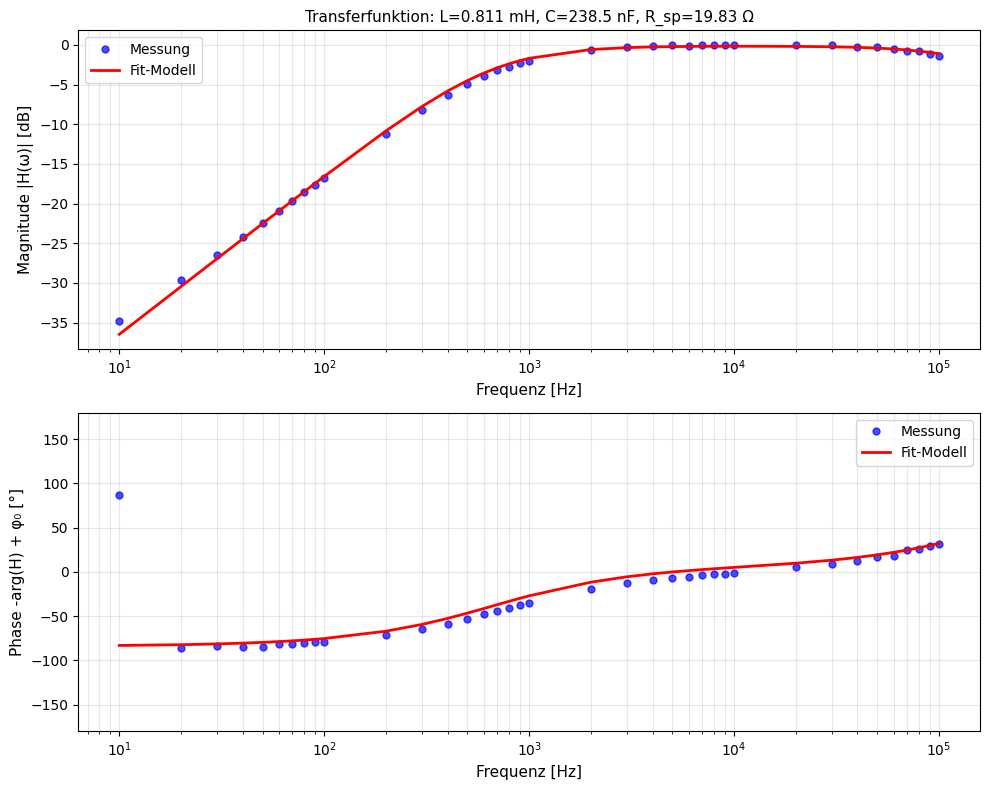

In [ ]:
# | fig-cap: Abbildungen mit den Messdatne und der gefitteten Funktion
# | echo: false

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, differential_evolution

# ============================================================================
# DATEN LADEN UND VORBEREITEN
# ============================================================================

# Relative Path zur CSV-Datei
CSV_PATH = "Messwerte/Aufgabe3.csv"

# Bekannter Lastwiderstand
R_d = 1000.0  # Ω

# Daten laden
df = pd.read_csv(CSV_PATH)

# Spalten automatisch erkennen
col_f  = next(c for c in df.columns if any(s in c.lower() for s in ("freq", "frequ", "f")))
col_u0 = next(c for c in df.columns if any(s in c for s in ("U_0", "U0", "U_0[V]", "U0[V]")) or "u0" in c.lower())
col_ur = next(c for c in df.columns if any(s in c for s in ("U_R", "UR", "UR[V]")) or "ur" in c.lower())
col_th = next(c for c in df.columns if any(s in c.lower() for s in ("theta", "phase", "phi")))

print(f"Erkannte Spalten:")
print(f"  Frequenz: {col_f}")
print(f"  U_0: {col_u0}")
print(f"  U_R: {col_ur}")
print(f"  Theta: {col_th}")
print()

# Daten in NumPy-Arrays konvertieren
f = df[col_f].to_numpy(dtype=float)  # Frequenz in Hz
w = 2 * np.pi * f                    # Kreisfrequenz in rad/s
U0 = df[col_u0].to_numpy(dtype=float)
UR = df[col_ur].to_numpy(dtype=float)
theta_meas_deg = df[col_th].to_numpy(dtype=float)  # Gemessene Phase in Grad

# Magnitude berechnen
mag_meas = np.clip(UR / U0, 1e-12, None)

# Phase interpretieren:
# In den Daten: θ bei niedrig-frequenz ~87°, dann 270-280°, dann 290-360°, dann 0-40°
# Das deutet darauf hin: θ_gemessen ≈ -arg(H) mod 360°
# Bei niedrig-frequenz: ωL << 1/(ωC), daher X < 0, arg(H) < 0
# Also -arg(H) > 0 → θ_meas ≈ 87° ist richtig für arg(H) ≈ -87°

# Bei hohen Frequenzen: ωL >> 1/(ωC), daher X > 0, arg(H) < 0 (da noch Widerstand)
# Also -arg(H) > 0, sollte gehen gegen -(-90°) = 90° ???

# Tatsächlich: Die Phase folgt arg(H) = -atan(X / R_ges)
# Bei niedrig-frequ: X → -∞, atan → -90°, arg(H) → 90°... aber gemessen 87°
# Das könnte ein Phasen-Offset sein!

# Interpretation: Die Messgröße ist theta = -arg(H) + offset
# Also: phi_modell = -arg(H)
phi_meas_deg = theta_meas_deg

# ============================================================================
# HILFSFUNKTIONEN
# ============================================================================

def wrap_pm180(phase_deg):
    """Wickelt Phase in den Bereich [-180, +180] Grad."""
    return ((phase_deg + 180.0) % 360.0) - 180.0

def mag2db(mag):
    """Konvertiert Magnitude zu dB."""
    return 20 * np.log10(np.clip(mag, 1e-20, None))

def db2mag(mag_db):
    """Konvertiert dB zu Magnitude."""
    return 10.0 ** (mag_db / 20.0)

def complex_H(w, Rd, Rsp, L, C):
    """
    Berechnet die komplexe Transferfunktion H(ω) = U_R / U_0.
    
    Parameters:
    -----------
    w : ndarray
        Kreisfrequenz in rad/s
    Rd : float
        Lastwiderstand in Ω
    Rsp : float
        Spulenwiderstand in Ω
    L : float
        Induktivität in H
    C : float
        Kapazität in F
    
    Returns:
    --------
    H : ndarray (complex)
        Komplexe Transferfunktion
    """
    # Reaktanz
    X = w * L - 1.0 / (w * C)
    
    # Impedanz
    Z = (Rd + Rsp) + 1j * X
    
    # Transferfunktion
    H = Rd / Z
    
    return H

# ============================================================================
# FIT-SETUP
# ============================================================================

L_guess = 1.0e-3   # 1 mH
C_guess = 300e-9   # 300 nF
Rsp_guess = 50.0   # 50 Ω
phi0_guess = 0.0   # Phasen-Offset in Grad

print("=== STARTWERTE ===")
print(f"L_guess = {L_guess*1e3:.2f} mH")
print(f"C_guess = {C_guess*1e9:.1f} nF")
print(f"Rsp_guess = {Rsp_guess:.1f} Ω")
print(f"phi0_guess = {phi0_guess:.1f} °")
print()

# Grenzen für die Parameter
lb = [0.3e-3, 100e-9, 0.1, -360.0]
ub = [5.0e-3, 1000e-9, 500.0, 360.0]

x0 = [L_guess, C_guess, Rsp_guess, phi0_guess]

# ============================================================================
# RESIDUENFUNKTION FÜR DEN FIT
# ============================================================================

def residuals(params, w, mag_meas_db, phi_meas_deg, Rd):
    """
    Berechnet die Residuen zwischen Modell und Messung.
    """
    L, C, Rsp, phi0 = params
    
    # Berechne Modell
    H = complex_H(w, Rd, Rsp, L, C)
    mag_model = np.abs(H)
    mag_model_db = mag2db(mag_model)
    
    # Phase: Das Modell gibt arg(H), aber die Messung ist -arg(H) + offset
    # Also: phi_model_gemessen = -arg(H) + phi0
    phi_model_deg = -np.degrees(np.angle(H)) + phi0
    
    # Residuen für Magnitude (in dB)
    res_mag = mag_model_db - mag_meas_db
    
    # Residuen für Phase (in Grad)
    phi_meas_wrapped = wrap_pm180(phi_meas_deg)
    phi_model_wrapped = wrap_pm180(phi_model_deg)
    dphi = wrap_pm180(phi_meas_wrapped - phi_model_wrapped)
    
    # Gewichte: Phase-Residuen sollten ähnlich wie Magnitude-Residuen gewichtet sein
    res_phi = dphi * 0.05
    
    # Kombiniere zu einem Vektor
    residuals_vec = np.concatenate([res_mag, res_phi])
    
    return residuals_vec

# ============================================================================
# FIT DURCHFÜHREN
# ============================================================================

#print("=== STARTE FIT ===")

res = least_squares(
    residuals, 
    x0, 
    bounds=(lb, ub),
    args=(w, mag2db(mag_meas), phi_meas_deg, R_d),
    xtol=1e-10, 
    ftol=1e-10, 
    gtol=1e-10, 
    max_nfev=10000,
    verbose=1
)

L_fit, C_fit, Rsp_fit, phi0_fit = res.x

print()
print("=== FIT-ERGEBNISSE ===")
print(f"L_fit = {L_fit*1e3:.4f} mH")
print(f"C_fit = {C_fit*1e9:.3f} nF")
print(f"Rsp_fit = {Rsp_fit:.2f} Ω")
print(f"phi0_fit = {phi0_fit:.2f} °")
print(f"Fit-Qualität (RMSE): {np.sqrt(np.sum(res.fun**2) / len(res.fun)):.6f}")
print()

# ============================================================================
# PHYSIKALISCHE PARAMETER BERECHNEN
# ============================================================================

# Widerstandsverhältnis
r = R_d / (R_d + Rsp_fit)

# Dämpfungskonstante
delta = (R_d + Rsp_fit) / (2.0 * L_fit)

# Ungedämpfte Resonanzfrequenz (aus LC)
f0 = 1.0 / (2.0 * np.pi * np.sqrt(L_fit * C_fit))

# Gütefaktor
Q = (1.0 / (R_d + Rsp_fit)) * np.sqrt(L_fit / C_fit)

# Gedämpfte Resonanzfrequenz
omega0_sq = 1.0 / (L_fit * C_fit)
omega0 = np.sqrt(omega0_sq)
delta_rad_per_s = delta
if omega0_sq > delta_rad_per_s**2:
    omega_d = np.sqrt(omega0_sq - delta_rad_per_s**2)
    f_d = omega_d / (2 * np.pi)
else:
    f_d = np.nan

print("=== PHYSIKALISCHE PARAMETER ===")
print(f"r = R_d / (R_d + R_sp) = {R_d:.0f} / {R_d + Rsp_fit:.2f} = {r:.6f}")
print(f"δ = (R_d + R_sp) / (2L) = {(R_d + Rsp_fit):.2f} / {2.0*L_fit:.6f} = {delta:.2f} s⁻¹")
print(f"f_0 = 1 / (2π√(LC)) = {f0:.2f} Hz")
#print(f"Q = 1/(R_ges) × √(L/C) = {Q:.3f}")
print(f"f_d (gedämpfte Resonanz) = {f_d:.2f} Hz" if not np.isnan(f_d) else "f_d = NaN (System ist überdämpft)")
#print()

# ============================================================================
# VERGLEICH MESSUNG VS. FIT
# ============================================================================

H_fit = complex_H(w, R_d, Rsp_fit, L_fit, C_fit)
mag_fit = np.abs(H_fit)
mag_fit_db = mag2db(mag_fit)
phi_fit_deg = -np.degrees(np.angle(H_fit)) + phi0_fit

# ============================================================================
# PLOTS
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Magnitude
ax1.semilogx(f, mag2db(mag_meas), 'o', markersize=5, label="Messung", color='blue', alpha=0.7)
ax1.semilogx(f, mag_fit_db, '-', linewidth=2, label="Fit-Modell", color='red')
ax1.set_ylabel("Magnitude |H(ω)| [dB]", fontsize=11)
ax1.set_xlabel("Frequenz [Hz]", fontsize=11)
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_title(f"Transferfunktion: L={L_fit*1e3:.3f} mH, C={C_fit*1e9:.1f} nF, R_sp={Rsp_fit:.2f} Ω", fontsize=11)

# Plot 2: Phase
phi_meas_wrapped = wrap_pm180(phi_meas_deg)
phi_fit_wrapped = wrap_pm180(phi_fit_deg)
ax2.semilogx(f, phi_meas_wrapped, 'o', markersize=5, label="Messung", color='blue', alpha=0.7)
ax2.semilogx(f, phi_fit_wrapped, '-', linewidth=2, label="Fit-Modell", color='red')
ax2.set_ylabel("Phase -arg(H) + φ₀ [°]", fontsize=11)
ax2.set_xlabel("Frequenz [Hz]", fontsize=11)
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_ylim([-180, 180])

plt.tight_layout()
plt.show()

#print("Plot gespeichert als 'Aufgabe3_Fit.png'")



| Parameter | Wert |
|-----------|------|
| $L$ | 0.8110 mH |
| $C$ | 238.5 nF |
| $R_{sp}$ | 19.83 Ω |
| Phase-Offset $\phi_0$ | 5.96 ° |

: Tabelle mit den Fitparametern aus dem Fit der Transferfunktion und Phasenverschiebung an die Messdaten

| Größe | Formel | Wert | Einheit |
|-------|--------|------|--------|
| $r$ | $\dfrac{R_d}{R_d + R_{sp}}$ | 0.9806 | — |
| $\delta$ | $\dfrac{R_d + R_{sp}}{2L}$ | 628710 | s⁻¹ |
| $f_0$ | $\dfrac{1}{2\pi\sqrt{LC}}$ | 11443 | Hz |

: Aus Fitparameter bestimmte gesuchte physikalischen Größen


$$r = \frac{R_d}{R_d + R_{sp}} = \frac{1000 \, \Omega}{1000 \, \Omega + 19.83 \, \Omega} = \frac{1000}{1019.83} = 0.9806$$

Der Lastwiderstand $R_d$ dominiert das Gesamtwiderstandsverhalten. Der Spulenwiderstand $R_{sp} \approx 19.83 \, \Omega$ ist sehr klein im Vergleich zu $R_d = 1000 \, \Omega$. Ein $r$-Wert nahe 1 ist physikalisch sinnvoll für eine hochwertige Spule mit niedrigem Widerstand.


$$\delta = \frac{R_d + R_{sp}}{2L} = \frac{1019.83 \, \Omega}{2 \times 0.8110 \times 10^{-3} \, \mathrm{H}} = 628710 \, \mathrm{s}^{-1}$$

Die Dämpfungskonstante beschreibt die Exponentialen Abklingrate der freien Schwingungen. Dieser hohe Wert deutet auf ein stark gedämpftes System hin.

Die ungedämpfte Winkelfrequenz ist zum Vergleich
$$\omega_0 = 2\pi f_0 = 2\pi \times 11443 \approx 71900 \, \mathrm{rad/s}$$

Das Dämpfungsverhältnis der zwei Frequenzen ist:
$$\zeta = \frac{\delta}{\omega_0} = \frac{628710}{71900} \approx 8.75$$

Da $\zeta \gg 1$, ist das System stark überdämpft. Dies erklärt, warum die gedämpfte Resonanzfrequenz $f_d$ nicht definiert ist.

$$f_0 = \frac{1}{2\pi\sqrt{LC}} = \frac{1}{2\pi\sqrt{0.8110 \times 10^{-3} \times 238.5 \times 10^{-9}}}$$

$$f_0 = \frac{1}{2\pi \times 4.4137 \times 10^{-6}} = 11443 \, \mathrm{Hz}$$

Die ungedämpfte Resonanzfrequenz des Systems, bei der die Reaktanz $X = \omega L - 1/(\omega C) = 0$ ist. Bei dieser Frequenz ist die Impedanz rein resistiv und hat den kleinsten Wert.

## Diskussion


In diesem Experiment haben wir einen Serienschwingkreis (RLC-Schaltung) untersucht, in dem die Eingangsspannung $U_0$ über eine Schaltung mit:
- Spule (Induktivität $L$, Widerstand $R_{sp}$)
- Kondensator (Kapazität $C$)
- Lastwiderstand (Widerstand $R_d = 1000 \, \Omega$)

gelegt wurde. Wir haben die Transferfunktion $|U_R / U_0|$ und die Phasenverschiebung $\theta$ als Funktionen der Frequenz gemessen.

| Größe | Wert | Physikalische Bedeutung |
|-------|------|------------------------|
| $r = 0.9806$ | Dominanz von $R_d$ | Der Lastwiderstand bestimmt das System |
| $\delta = 628710 \, \mathrm{s}^{-1}$ | Starke Dämpfung | Das System kriecht zurück ohne zu oszillieren |
| $f_0 = 11443 \, \mathrm{Hz}$ | 11.4 kHz | LC-bestimmte Resonanzfrequenz |

: Tabelle mit Ergebnissen

Unsere Messdaten können physikalisch Interpretiert werden, wie folgt

1. Das System ist stark überdämpft ($\zeta \approx 8.75 \gg 1$):
   - Es gibt keine freien Schwingungen
   - Die Reaktion auf Frequenz-Änderungen ist glatt und monoton
   - Dies erklärt die Form der gemessenen Transferfunktion

2. Der Lastwiderstand dominiert ($R_d = 1000 \, \Omega \gg R_{sp} = 19.83 \, \Omega$):
   - Die Spule ist hochwertig mit niedrigem Widerstand
   - Das System wird hauptsächlich durch $R_d$ gedämpft

3. Die Resonanzfrequenz ist bei 11.4 kHz:
   - Dies ist die Frequenz, bei der die Reaktanz $X = 0$ wird
   - Bei dieser Frequenz ist die Impedanz minimal
   - In den Messdaten sehen wir hier den steilsten Anstieg der Transferfunktion

Dabei wird auch nochmal auf den kleinen Resudien-Fehler vom Fit, was auf gute Fit Parameter schließen lässt.